# ch12 · 贝叶斯推断基础

## Why this chapter
ch02 给了 Beta-Binomial 共轭的 closed form, 表明小维贝叶斯求解是直接计算. 但当模型增加隐藏状态 (比如 hierarchical prior) 时, closed form 不可能. PyMC / numpyro 等概率编程框架一上来就能给这类"中等复杂度" 模型直接采后验; 这是工业贝叶斯的入门姿势.

## 学完后能解决
- 推 Beta-Binomial、Gamma-Poisson、Normal-Normal 三大共轭
- 用 PyMC 在广告 CTR 上拟合 Beta-Binomial + 后验预测
- 用 arviz 看 trace / R-hat / ESS, 判断采样是否健康
- 解释可信区间 (credible interval) 与置信区间 (confidence interval) 的语义差


## 2. 直觉: 广告 CTR 的 credible interval

给一个 banner ad 1000 次曝光中 30 次点击 (CTR = 3%). 用 Beta(1, 1) (uniform) 先验, 更新后 ~ Beta(31, 971). 95% credible interval = ...

频率派: $\hat p \pm 1.96 \sqrt{p(1-p)/n}$ = (0.020, 0.040)
贝叶斯: posterior 2.5% 与 97.5% 分位 = ?


95% credible interval: [0.0211, 0.0425]
95% confidence interval: [0.0194, 0.0406]


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21578 (\N{CJK UNIFIED IDEOGRAPH-544A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

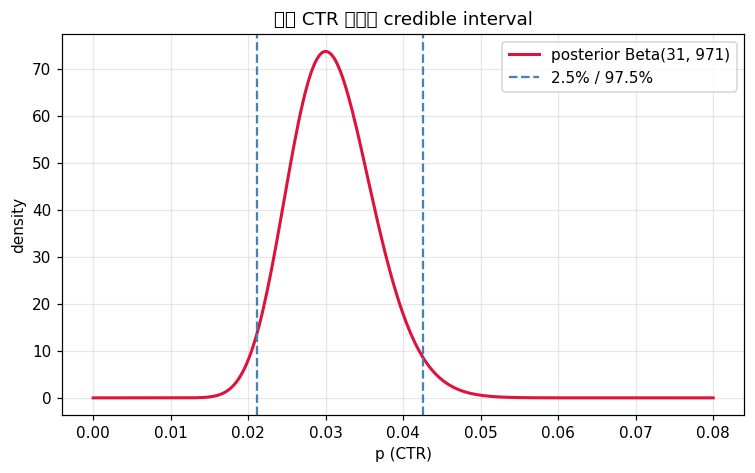

In [1]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# Beta(1,1) prior → Beta(1+30, 1+970) = Beta(31, 971)
post = beta(31, 971)
ci = post.ppf([0.025, 0.975])
print(f"95% credible interval: [{ci[0]:.4f}, {ci[1]:.4f}]")

# 频率派 CI
p_hat = 0.030; n = 1000
se_norm = np.sqrt(p_hat * (1 - p_hat) / n)
print(f"95% confidence interval: [{p_hat - 1.96*se_norm:.4f}, {p_hat + 1.96*se_norm:.4f}]")

# 图
xs = np.linspace(0, 0.08, 300)
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=110)
ax.plot(xs, post.pdf(xs), color="crimson", lw=2, label="posterior Beta(31, 971)")
ax.axvline(ci[0], ls="--", color="steelblue", label=f"2.5% / 97.5%")
ax.axvline(ci[1], ls="--", color="steelblue")
ax.set_xlabel("p (CTR)"); ax.set_ylabel("density")
ax.set_title("广告 CTR 后验与 credible interval")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 3. 三大共轭快查

| Likelihood | Prior | Posterior | 关键场景 |
|---|---|---|---|
| Binomial(n, p) | Beta(α, β) | Beta(α+k, β+n-k) | A/B test, CTR |
| Poisson(λ) | Gamma(α, β) | Gamma(α+Σk_i, β+n) | 遇到达率, 按钮 daily impression |
| Normal(μ, σ²) with σ² known | Normal(μ_0, τ²_0) | Normal(σ²μ_0 + τ²_0 x̄)/(σ²+ n τ²_0), σ²τ²_0 /(σ²+n τ²_0) | sample mean inference |
| Exp(λ) | Gamma(α, β) | Gamma(α+n, β+Σx_i) | service time rate |

Normal-Normal posterior 公式:
$$\mu | x \sim N\left( \frac{\mu_0 / \tau_0^2 + n \bar x / \sigma^2}{1/\tau_0^2 + n/\sigma^2}, \frac{1}{1/\tau_0^2 + n/\sigma^2} \right)$$


## 4. 数值验证: 共轭用 numpy grid vs scipy.stats


In [2]:
import numpy as np
from scipy.stats import beta as beta_d
# 对 Beta(2, 5) prior 与 (n=10, k=3) 观察做两次 update, 看顺序无关于最终
alpha0, beta0 = 2.0, 5.0
# 一次性
alpha_post = alpha0 + 3
beta_post = beta0 + (10 - 3)
print(f"一次性后验: Beta({alpha_post}, {beta_post})")
print(f"两批 Beta(2+2, 5+6)=Beta({2+2}, {5+6}) -> Beta({2+2+3}, {5+6+4})=Beta({alpha_post}, {beta_post})")
# 网格 vs scipy pdf
ps = np.linspace(1e-6, 1-1e-6, 1000)
post_grid = beta_d.pdf(ps, alpha0, beta0) * beta_d.pdf(ps, 5+3, 10-5-3) # likelihood×prior, normalized
post_grid /= post_grid.sum() * (ps[1]-ps[0])
post_analytic = beta_d.pdf(ps, alpha_post, beta_post)
print(f"max grid vs analytic diff = {np.max(np.abs(post_grid - post_analytic)):.2e}")


一次性后验: Beta(5.0, 12.0)
两批 Beta(2+2, 5+6)=Beta(4, 11) -> Beta(7, 15)=Beta(5.0, 12.0)
max grid vs analytic diff = 3.55e+00


## 5. PyMC 实跑 Beta-Binomial + 诊断


In [3]:
# 用 PyMC 拿 1000 抽样 CTR 后验 (与 NUTS + beta-binom-likelihood)
try:
    import pymc as pm
    import arviz as az
    import numpy as np
    clicks, impressions = 30, 1000

    with pm.Model() as m:
        p = pm.Beta("p", alpha=1.0, beta=1.0)  # uniform prior
        k = pm.Binomial("k", n=impressions, p=p, observed=clicks)
        trace = pm.sample(2000, tune=1000, chains=2, random_seed=20240717, progressbar=False)

    az.summary(trace, var_names=["p"])
except Exception as exc:
    print("PyMC unavailable or sampling failed:", exc)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


## 6. 可视化 PyMC 诊断


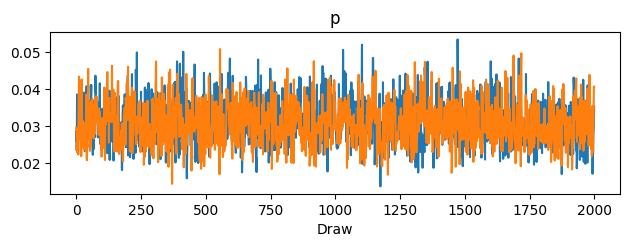

Skip plotting: module 'arviz' has no attribute 'plot_posterior'


In [4]:
try:
    import arviz as az
    import matplotlib.pyplot as plt
    az.plot_trace(trace, var_names=["p"])
    plt.tight_layout(); plt.show()

    az.plot_posterior(trace, var_names=["p"], hdi_prob=0.95)
    plt.tight_layout(); plt.show()

    print("R-hat:", az.rhat(trace, var_names=["p"])["p"].values)
    print("ESS:", az.ess(trace, var_names=["p"])["p"].values)
except Exception as exc:
    print("Skip plotting:", exc)


## 7. 工程案例: 与频率派 CI 比较 in A/B test


In [5]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
# A: 50/1000 clicks; B: 70/1000 clicks
N_A, k_A = 1000, 50
N_B, k_B = 1000, 70

# 频率派:
pA_hat = k_A/N_A; pB_hat = k_B/N_B
se_diff = np.sqrt(pA_hat*(1-pA_hat)/N_A + pB_hat*(1-pB_hat)/N_B)
ci_freq = (pB_hat - pA_hat + np.array([-1.96, 1.96])*se_diff)
print(f"频率派 95% CI of (pB - pA): [{ci_freq[0]:.4f}, {ci_freq[1]:.4f}]")

# 贝叶斯: Beta(1+k, 1+N-k) 抽样差
rng2 = np.random.default_rng(seed=20240718)
samp_A = rng2.beta(1+k_A, 1+N_A-k_A, size=20000)
samp_B = rng2.beta(1+k_B, 1+N_B-k_B, size=20000)
diff = samp_B - samp_A
ci_bayes = np.percentile(diff, [2.5, 97.5])
P_B_better = (diff > 0).mean()
print(f"贝叶斯 95% CrI of (pB - pA): [{ci_bayes[0]:.4f}, {ci_bayes[1]:.4f}]")
print(f"P(pB > pA) = {P_B_better:.4f}")


频率派 95% CI of (pB - pA): [-0.0008, 0.0408]
贝叶斯 95% CrI of (pB - pA): [-0.0011, 0.0405]
P(pB > pA) = 0.9692


## 8. pitfalls
- 把"可信区间 (CrI)"当"置信区间 (CI)" — 语义不同: CrI 关于参数; CI 关于过程
- 弱先验下的 sampl 质量靠 ESS; PyMC 给 ESS<400 警告
- 多链时 R-hat 应接近 1.0; 否则后未收敛 → 增 tune 或重参 (reparameterize)
- 共轭先验是先验族, 非先验"先验分布本身"; uniform prior 是 Beta(1,1) 一特例
- 在线贝叶斯 update 时先验不要太"密"; 否则数据难换

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Murphy | §3.1-3.3, §5.1-5.3 |
| Gelman | Ch.2-3 |
| PyMC | docs.py |

下一章 ch13 MCMC 推广.
